In [1]:
%pip install kagglehub pyarrow


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhoogla/unswnb15")

print("Path to dataset files:", path)

/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/mpersson/.cache/kagglehub/datasets/dhoogla/unswnb15/versions/5



Training set shape: (175341, 36)
Testing set shape: (82332, 36)

--- Head ---


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-n

Series([], dtype: int64)


--- Duplicate rows ---
78519

--- Numeric summary ---


...

,count,unique,top,freq
proto,175341,133,tcp,79946
service,175341,13,-,94168
state,175341,9,INT,82275
attack_cat,175341,10,Normal,56000



--- Value counts: label ---


label
1    119341
0     56000
Name: count, dtype: int64


--- Value counts: attack_cat ---


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

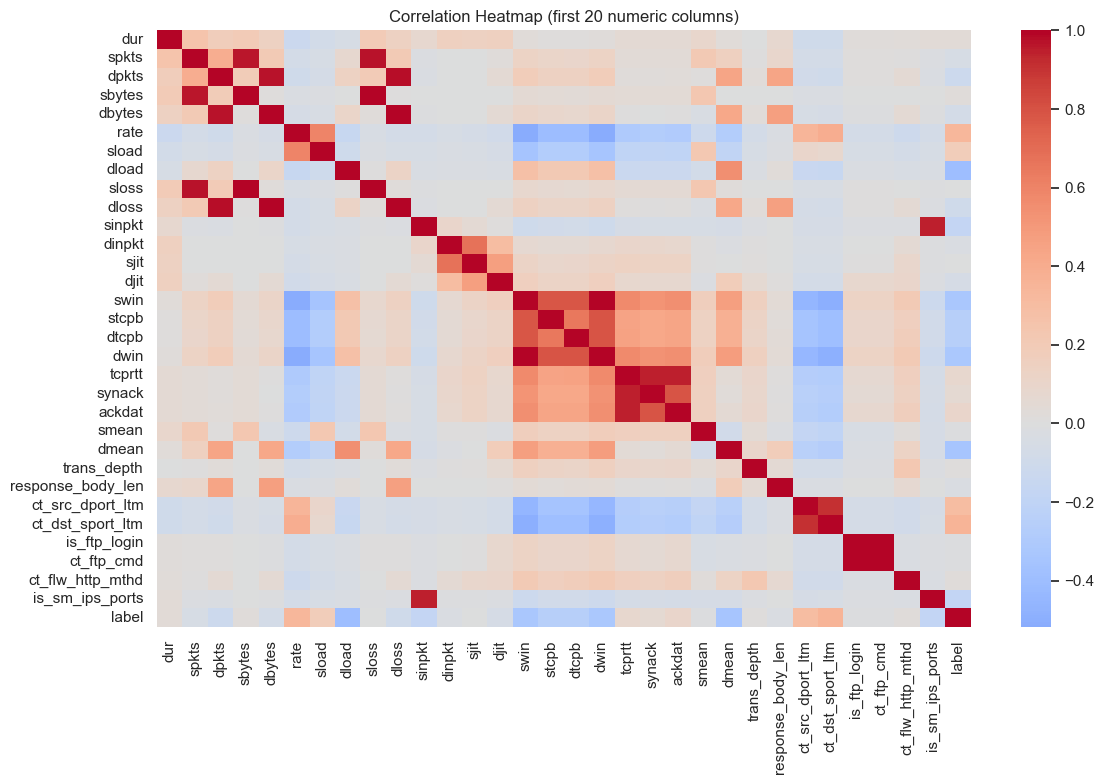

In [3]:
import os
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

test_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_testing-set.parquet"))
train_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_training-set.parquet"))

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# Quick EDA of the training set
print("\n--- Head ---")
display(train_df.head())

print("\n--- Info ---")
train_df.info()

print("\n--- Missing values (top 20) ---")
missing = train_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

print("\n--- Duplicate rows ---")
print(train_df.duplicated().sum())

print("\n--- Numeric summary ---")
display(train_df.describe(include=["number"]).T)

print("\n--- Categorical summary ---")
cat_cols = train_df.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    display(train_df[cat_cols].describe().T.head(20))

# Target distribution
for target_col in ["label", "attack_cat", "Class", "class"]:
    if target_col in train_df.columns:
        print(f"\n--- Value counts: {target_col} ---")
        display(train_df[target_col].value_counts(dropna=False).head(20))

# Basic visual EDA
sns.set(style="whitegrid")

# Missing values plot (top 15)
top_missing = missing[missing > 0].head(15)
if not top_missing.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_missing.values, y=top_missing.index, palette="viridis")
    plt.title("Top Missing Columns")
    plt.xlabel("Missing Count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# Correlation heatmap for numeric columns
num_cols = train_df.select_dtypes(include=["number"]).columns
if len(num_cols) > 1:
    sample_num_cols = num_cols  # limit for readability
    corr = train_df[sample_num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (first 20 numeric columns)")
    plt.tight_layout()
    plt.show()

In [4]:
# Check null/NaN values in train and test sets
for name, df in [("train_df", train_df), ("test_df", test_df)]:
    null_counts = df.isna().sum()
    total_nulls = int(null_counts.sum())
    
    print(f"\n{name} -> total null/NaN values: {total_nulls}")
    print(f"{name} -> columns with null/NaN: {(null_counts > 0).sum()}")
    
    if total_nulls > 0:
        display(null_counts[null_counts > 0].sort_values(ascending=False))


train_df -> total null/NaN values: 0
train_df -> columns with null/NaN: 0

test_df -> total null/NaN values: 0
test_df -> columns with null/NaN: 0


In [5]:
from sklearn.preprocessing import StandardScaler

# Drop duplicate rows
train_before, test_before = len(train_df), len(test_df)
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

# Normalize numeric feature columns (fit on train, apply to test)
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
exclude_cols = {"label", "Class", "class"}
if "target" in globals():
    exclude_cols.add(target)

feature_cols = [c for c in numeric_cols if c not in exclude_cols and c in test_df.columns]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols].astype("float64"))
train_df[feature_cols] = pd.DataFrame(train_scaled, columns=feature_cols, index=train_df.index)
    
test_scaled = scaler.transform(test_df[feature_cols].astype("float64"))
test_df[feature_cols] = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

print(f"Train duplicates removed: {train_before - len(train_df)}")
print(f"Test duplicates removed: {test_before - len(test_df)}")
print(f"Standardized feature count: {len(feature_cols)}")

Train duplicates removed: 78519
Test duplicates removed: 32361
Standardized feature count: 31


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

target = "label"

train_df

y_train = train_df[target]
X_train = train_df.drop(columns=[target, "attack_cat"])

y_test = test_df[target]
X_test = test_df.drop(columns=[target, "attack_cat"])

# Baseline: always predict the most frequent class from training data
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

print(f"Target column: {target}")
print(f"Baseline strategy: {baseline_clf.strategy}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Target column: label
Baseline strategy: most_frequent
Accuracy: 0.6326
Balanced Accuracy: 0.5000

Classification report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77     31610
           1       0.00      0.00      0.00     18361

    accuracy                           0.63     49971
   macro avg       0.32      0.50      0.39     49971
weighted avg       0.40      0.63      0.49     49971

Confusion matrix:
[[31610     0]
 [18361     0]]


Target column: label
Model: RandomForestClassifier
Accuracy: 0.8184
Balanced Accuracy: 0.8448

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     31610
           1       0.68      0.94      0.79     18361

    accuracy                           0.82     49971
   macro avg       0.82      0.84      0.82     49971
weighted avg       0.86      0.82      0.82     49971

Confusion matrix:
[[23553  8057]
 [ 1018 17343]]


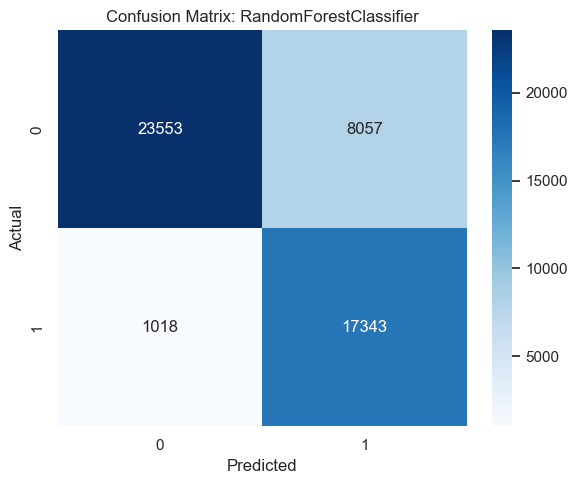

In [9]:
from sklearn.ensemble import RandomForestClassifier

# One-hot encode categorical features and align train/test columns
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# Train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_clf.fit(X_train_enc, y_train)

# Predict and evaluate
y_pred_rf = rf_clf.predict(X_test_enc)

print(f"Target column: {target}")
print("Model: RandomForestClassifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_rf):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: RandomForestClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on already encoded features
lr_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="liblinear"
)
lr_clf.fit(X_train_enc, y_train)

# Predict and evaluate
y_pred_lr = lr_clf.predict(X_test_enc)

print(f"Target column: {target}")
print("Model: LogisticRegression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_lr):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Target column: label
Model: LogisticRegression
Accuracy: 0.7257
Balanced Accuracy: 0.7697

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.60      0.74     31610
           1       0.58      0.94      0.71     18361

    accuracy                           0.73     49971
   macro avg       0.76      0.77      0.73     49971
weighted avg       0.81      0.73      0.73     49971

Confusion matrix:
[[19087 12523]
 [ 1182 17179]]
